In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
X = np.arange(0,30,0.27)
print(X[0:4])

#Generate y = m * x + c
y = 0.1999 * X + 4.2999
print(y[0:4])
print(X.shape,y.shape)


[0.   0.27 0.54 0.81]
[4.2999   4.353873 4.407846 4.461819]
(112,) (112,)


In [15]:
split = int(X.shape[0]*0.8)
split

89

In [16]:
X_train, y_train = X[:split],y[:split]
x_test,y_test = X[split:],y[split:]



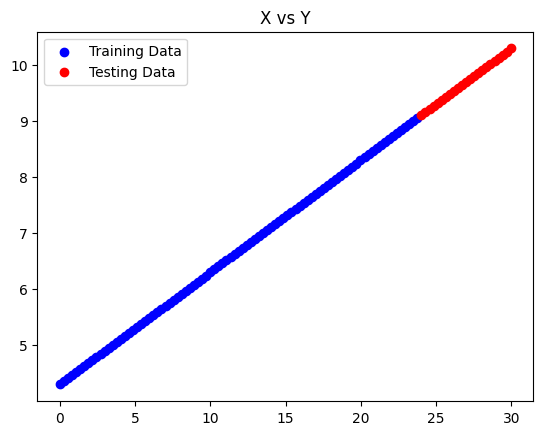

In [39]:
def plot_data(X_train=X_train,X_test=x_test,y_train=y_train,y_test=y_test,predictions=None):
    plt.scatter(X_train,y_train,c='b',label='Training Data')
    plt.scatter(X_test,y_test,c='r',label='Testing Data')
    if predictions is not None:
        plt.scatter(X_test,predictions,c='y',label='Prediction Data')
    plt.title("X vs Y")
    plt.legend()
    
plot_data()
    

In [40]:
X_mean = np.mean(X_train)
y_mean = np.mean(y_train)
cov_x_y = ((1/X_train.shape[0])*np.sum((X_train-X_mean)*(y_train - y_mean)))
cov_x = (1/X_train.shape[0])*np.sum(np.square((X_train-X_mean)))

m = cov_x_y/cov_x
c = y_mean - m * X_mean
print(f"y = {m} * x + {c}")

y = 0.1999 * x + 4.2999


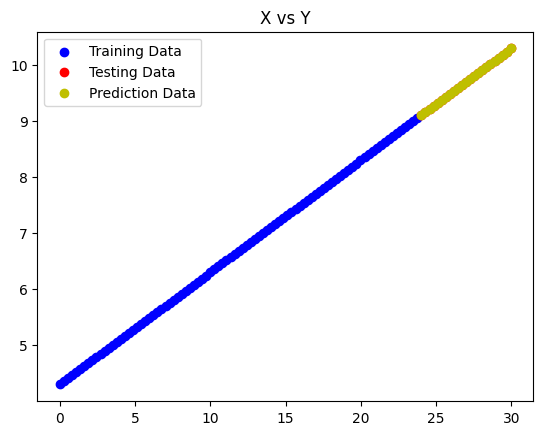

In [ ]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
#Train
lr_model.fit(X_train.reshape(-1,1),y_train.reshape(-1,1))
#Get prediction
y_preds = lr_model.predict(x_test.reshape(-1,1))

#plot
plot_data(predictions = y_preds)

In [45]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
x_test_sm = sm.add_constant(x_test)
# print(x_test_sm[:2])
#Fit the mode
model = sm.OLS(y_train,X_train_sm).fit()
#view the summary
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.015e+31
Date:                Tue, 10 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:21:17   Log-Likelihood:                 2884.2
No. Observations:                  89   AIC:                            -5764.
Df Residuals:                      87   BIC:                            -5759.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2999   4.34e-16   9.91e+15      0.000       4.300       4.300
x1             0.1999   3.15e-17   6.34e+15      0.000       0.200       0.200
==============================================================================
Omnibus:                        8.568   Durbin-Watson:                   0.172
Prob(Omnibus):                  0.014   Jarque-Bera (JB):                8.982
Skew:                           0.778   Prob(JB):                       0.0112
Kurtosis:                       2.973   Cond. No.                         27.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
X1 = np.arange(10,30,0.27)
X2 = np.arange(50,70,0.27)

y = 1.123 * X1 + 2.123 * X2 + 3.123
df = pd.DataFrame({'X1':X1,'X2':X2,"y":y})
X_data = df.drop(columns=['y'])
y_data = df['y']

X_train,X_test,y_train,y_test = train_test_split(X_data,y_data,test_size=0.2)
X_train_sm = sm.add_constant(X_train)
x_test_sm = sm.add_constant(X_test)
# print(x_test_sm[:2])
#Fit the mode
model = sm.OLS(y_train,X_train_sm).fit()
#view the summary
model.summary()

y_preds = model.predict(x_test_sm)
# plot_data(X_train=X_train,X_test=X_test,y_train=y_train,y_test=y_test,predictions=y_preds)


sdjfkj
